# Taylor Root Prediction — Reviewer Demo Notebook (v5)

This notebook is designed so a reviewer can **clone the repo and run everything with relative paths**, even when the notebook is executed from `notebooks/`.

What you can do here:
- (Optional) generate **root-regression** and **interval** NPZ datasets under `data/`
- (Optional) train models (ANN / LSTM / Anchored-MLP / Transformer interval predictor)
- run evaluation (K-sweep + baseline) and produce plots/reports

> Tip: start small (e.g., 20k samples) to verify reproducibility quickly.


In [2]:
from __future__ import annotations

from pathlib import Path
import os, sys, subprocess, shutil, textwrap
import json
import numpy as np

def find_repo_root(start: Path | None = None) -> Path:
    """Find repo root by walking up until we see required folders."""
    if start is None:
        start = Path.cwd().resolve()
    else:
        start = start.resolve()
    for p in [start] + list(start.parents):
        if (p / "configs").is_dir() and (p / "models").is_dir():
            return p
    raise RuntimeError("Could not find repo root (expected folders: configs/, models/).")

REPO = find_repo_root()
print("CWD :", Path.cwd())
print("REPO:", REPO)

# Make all relative paths resolve from repo root
os.chdir(REPO)
print("CHDIR ->", Path.cwd())

def R(rel: str | Path) -> Path:
    return (REPO / Path(rel)).resolve()

def ensure_dir(p: Path) -> None:
    p.mkdir(parents=True, exist_ok=True)

def run(cmd, env=None, cwd=None):
    """Run a command, printing stdout/stderr. Raises on failure."""
    cmd = [str(x) for x in cmd]
    print(">>", " ".join(cmd))
    r = subprocess.run(cmd, cwd=str(cwd or REPO), env=env, capture_output=True, text=True)
    if r.stdout:
        print(r.stdout)
    if r.returncode != 0:
        if r.stderr:
            print("----- STDERR -----")
            print(r.stderr)
        raise RuntimeError(f"Command failed (code={r.returncode})")
    return r

# Ensure imports like `import src...` work when scripts are executed via subprocess
BASE_ENV = os.environ.copy()
BASE_ENV["PYTHONPATH"] = str(REPO)


CWD : /home/seokjun/taylor-root-prediction/notebooks
REPO: /home/seokjun/taylor-root-prediction
CHDIR -> /home/seokjun/taylor-root-prediction


## 0) Dependencies

Minimum:
- numpy, pyyaml, tqdm
- torch (CPU or CUDA)
- matplotlib (for plots in evaluation)

Optional (only if you enable symbolic baselines in evaluation):
- sympy
- requests


In [3]:
# (Optional) quick sanity check
import importlib, platform

pkgs = ["numpy","yaml","tqdm","torch","matplotlib"]
missing = []
for p in pkgs:
    try:
        importlib.import_module(p if p!="yaml" else "yaml")
    except Exception:
        missing.append(p)
print("Missing:", missing)

import torch
print("Python :", platform.python_version())
print("Torch  :", torch.__version__)
print("CUDA?  :", torch.cuda.is_available())


Missing: []
Python : 3.10.18
Torch  : 2.5.1+cu121
CUDA?  : True


## 1) Configure a small reviewer run

These defaults are intentionally small so the notebook finishes in reasonable time.
Increase sizes/epochs if you want stronger models.


In [4]:
DEGREE = 25

# Recommended quick sizes for reviewers
N_TOTAL_ROOT = 20000
N_TOTAL_INTERVAL = 20000

# Output directories (ALWAYS under repo/data/)
OUT_ROOT_DIR = R("data/taylor_data_physchem_v4_deg25")
OUT_INTERVAL_DIR = R("data/taylor_data_physchem_v4_interval")
ensure_dir(OUT_ROOT_DIR)
ensure_dir(OUT_INTERVAL_DIR)

print("OUT_ROOT_DIR    :", OUT_ROOT_DIR)
print("OUT_INTERVAL_DIR:", OUT_INTERVAL_DIR)

train_npz = OUT_ROOT_DIR / f"taylor_deg{DEGREE}_train.npz"
val_npz   = OUT_ROOT_DIR / f"taylor_deg{DEGREE}_val.npz"
test_npz  = OUT_ROOT_DIR / f"taylor_deg{DEGREE}_test.npz"

itr_train_npz = OUT_INTERVAL_DIR / f"taylor_deg{DEGREE}_train.npz"
itr_val_npz   = OUT_INTERVAL_DIR / f"taylor_deg{DEGREE}_val.npz"
itr_test_npz  = OUT_INTERVAL_DIR / f"taylor_deg{DEGREE}_test.npz"


OUT_ROOT_DIR    : /home/seokjun/taylor-root-prediction/data/taylor_data_physchem_v4_deg25
OUT_INTERVAL_DIR: /home/seokjun/taylor-root-prediction/data/taylor_data_physchem_v4_interval


## 2) (Optional) Fix “dataset created at repo root” issue

If you previously generated datasets but they ended up in:
- `<repo>/taylor_data_physchem_v4_deg25/`
- `<repo>/taylor_data_physchem_v4_interval/`

this cell will move them into `data/` automatically.


In [5]:
def migrate_dataset_if_found(folder_name: str):
    wrong = REPO / folder_name
    correct = REPO / "data" / folder_name
    if wrong.exists() and wrong.is_dir():
        ensure_dir(correct.parent)
        if correct.exists():
            # If target already populated, keep it.
            if any(correct.iterdir()):
                print("[MIGRATE] target already populated:", correct)
                return
            else:
                shutil.rmtree(correct)
        print("[MIGRATE] moving", wrong, "->", correct)
        shutil.move(str(wrong), str(correct))

migrate_dataset_if_found("taylor_data_physchem_v4_deg25")
migrate_dataset_if_found("taylor_data_physchem_v4_interval")

print("[CHECK]")
print(" root dir exists   :", OUT_ROOT_DIR.exists())
print(" interval dir exists:", OUT_INTERVAL_DIR.exists())


[CHECK]
 root dir exists   : True
 interval dir exists: True


## 3) Generate datasets (NPZ) under `data/`

This notebook assumes your repo includes dataset generator scripts (recommended):
- `data_generation/generate_root_dataset_v4.py`  (root-regression NPZ)
- `data_generation/generate_interval_dataset_v4.py` (interval NPZ)

If your filenames differ, edit the paths below **once**, and the rest of the notebook will work.


In [6]:
# ---- generator script locations (edit if your repo uses different names) ----
gen_root = R("scripts/data/generate_dataset_physchem_v4.py")
gen_interval = R("scripts/data/generate_interval_dataset_physchem_v4.py")

print("gen_root    :", gen_root, "exists=", gen_root.exists())
print("gen_interval:", gen_interval, "exists=", gen_interval.exists())

# If scripts are missing, try to auto-discover by keyword
if not gen_root.exists():
    cands = list(REPO.rglob("*root*dataset*gen*.py")) + list(REPO.rglob("*generate*root*.py"))
    cands = [p for p in cands if p.is_file()]
    if cands:
        gen_root = cands[0]
        print("[AUTO] gen_root ->", gen_root)
if not gen_interval.exists():
    cands = list(REPO.rglob("*interval*dataset*gen*.py")) + list(REPO.rglob("*generate*interval*.py"))
    cands = [p for p in cands if p.is_file()]
    if cands:
        gen_interval = cands[0]
        print("[AUTO] gen_interval ->", gen_interval)

assert gen_root.exists(), "Root dataset generator script not found in repo."
assert gen_interval.exists(), "Interval dataset generator script not found in repo."

# ---- root regression dataset ----
need_root = (not train_npz.exists()) or (not val_npz.exists()) or (not test_npz.exists())
if need_root:
    run([
        sys.executable, str(gen_root),
        "--degree", str(DEGREE),
        "--n-total", str(N_TOTAL_ROOT),
        "--seed", "42",
        "--out-dir", str(OUT_ROOT_DIR),   # ABSOLUTE PATH to avoid CWD issues
        "--save-expr-str", "1",
    ], env=BASE_ENV, cwd=REPO)
else:
    print("[SKIP] root dataset already exists.")

# ---- interval dataset ----
need_interval = (not itr_train_npz.exists()) or (not itr_val_npz.exists()) or (not itr_test_npz.exists())
if need_interval:
    run([
        sys.executable, str(gen_interval),
        "--degree", str(DEGREE),
        "--n-total", str(N_TOTAL_INTERVAL),
        "--seed", "42",
        "--out-dir", str(OUT_INTERVAL_DIR),  # ABSOLUTE PATH
        "--save-expr-str", "1",
    ], env=BASE_ENV, cwd=REPO)
else:
    print("[SKIP] interval dataset already exists.")

print("[DATA CHECK]")
for p in [train_npz, val_npz, test_npz, itr_train_npz, itr_val_npz, itr_test_npz]:
    print(" ", p.relative_to(REPO), "exists=", p.exists())


gen_root    : /home/seokjun/taylor-root-prediction/scripts/data/generate_dataset_physchem_v4.py exists= True
gen_interval: /home/seokjun/taylor-root-prediction/scripts/data/generate_interval_dataset_physchem_v4.py exists= True
[SKIP] root dataset already exists.
[SKIP] interval dataset already exists.
[DATA CHECK]
  data/taylor_data_physchem_v4_deg25/taylor_deg25_train.npz exists= True
  data/taylor_data_physchem_v4_deg25/taylor_deg25_val.npz exists= True
  data/taylor_data_physchem_v4_deg25/taylor_deg25_test.npz exists= True
  data/taylor_data_physchem_v4_interval/taylor_deg25_train.npz exists= True
  data/taylor_data_physchem_v4_interval/taylor_deg25_val.npz exists= True
  data/taylor_data_physchem_v4_interval/taylor_deg25_test.npz exists= True


## 4) (Optional) Train models (YAML-driven)

All training scripts use environment variables (no CLI args needed):
- `TAYLOR_CFG` (or `CFG_PATH` for transformer)
- `TRAIN_NPZ`, `VAL_NPZ`, `TEST_NPZ`
- `OUT_DIR`
- `DEVICE`

By default, training cells are **commented out** to keep reviewer runtime reasonable.
Uncomment what you want to run.


In [7]:
import torch

def train_script(script_rel: str, cfg_rel: str, out_rel: str, train_path: Path, val_path: Path, test_path: Path | None):
    script = R(script_rel)
    cfg = R(cfg_rel)
    out_dir = R(out_rel)
    ensure_dir(out_dir)

    env = BASE_ENV.copy()
    env.update({
        "TAYLOR_CFG": str(cfg),
        "TRAIN_NPZ": str(train_path),
        "VAL_NPZ": str(val_path),
        "TEST_NPZ": (str(test_path) if test_path is not None else ""),
        "OUT_DIR": str(out_dir),
        "DEVICE": ("cuda" if torch.cuda.is_available() else "cpu"),
    })
    run([sys.executable, str(script)], env=env, cwd=REPO)

# ---- Uncomment the models you want to train ----

train_script("models/taylor_nn/ann.py",  "configs/taylor_root_ann.yaml",  "results/taylor_nn/ann",
             train_npz, val_npz, test_npz)

train_script("models/taylor_nn/lstm.py", "configs/taylor_root_lstm.yaml", "results/taylor_nn/lstm",
             train_npz, val_npz, test_npz)

train_script("models/taylor_nn/mlp.py",  "configs/taylor_root_mlp.yaml",  "results/taylor_nn/mlp",
             train_npz, val_npz, test_npz)


>> /home/seokjun/miniconda3/envs/action_recognition/bin/python /home/seokjun/taylor-root-prediction/models/taylor_nn/ann.py
[CONFIG] /home/seokjun/taylor-root-prediction/configs/taylor_root_ann.yaml
[DATA] train=800000 val=100000 test=100000
[NPZ] train coeff_key=coeffs, keys=['coeffs', 'root0', 'root1', 'root2', 'func_id', 'degree', 'template_str', 'norm_scale', 'root_count', 'roots', 'expr_str']
[SHAPE] coeff_dim(D)=26, num_roots=25
[MODEL] hidden_dim=25, layers=auto, act=tanh
[OUT] /home/seokjun/taylor-root-prediction/results/taylor_nn/ann
[ep=   1] train_loss=0.0996695  val_loss=0.085333
  -> save best: /home/seokjun/taylor-root-prediction/results/taylor_nn/ann/best.pt
[ep=   2] train_loss=0.0755342  val_loss=0.067131
  -> save best: /home/seokjun/taylor-root-prediction/results/taylor_nn/ann/best.pt
[ep=   3] train_loss=0.0619915  val_loss=0.058033
  -> save best: /home/seokjun/taylor-root-prediction/results/taylor_nn/ann/best.pt
[ep=   4] train_loss=0.0557657  val_loss=0.0538373
 

## 5) (Optional) Train Transformer interval predictor

The transformer script reads:
- `CFG_PATH`
- `TRAIN_NPZ`, `VAL_NPZ`, `TEST_NPZ`
- `OUT_DIR`, `DEVICE`, `MODE=train`

Uncomment to train.


In [8]:
def train_transformer():
    script = R("models/transformer/model.py")
    cfg = R("configs/transformer_interval.yaml")
    out_dir = R("results/transformer_interval")
    ensure_dir(out_dir)

    env = BASE_ENV.copy()
    env.update({
        "CFG_PATH": str(cfg),
        "TRAIN_NPZ": str(itr_train_npz),
        "VAL_NPZ": str(itr_val_npz),
        "TEST_NPZ": str(itr_test_npz),
        "OUT_DIR": str(out_dir),
        "DEVICE": ("cuda" if torch.cuda.is_available() else "cpu"),
        "MODE": "train",
    })
    run([sys.executable, str(script)], env=env, cwd=REPO)

# Uncomment to train transformer
train_transformer()


>> /home/seokjun/miniconda3/envs/action_recognition/bin/python /home/seokjun/taylor-root-prediction/models/transformer/model.py
[CFG]  /home/seokjun/taylor-root-prediction/configs/transformer_interval.yaml
[DATA] train=800000 val=100000 test=100000
[VOCAB] size=22  max_len=16 (rule=auto_top_1_percent_mean_x1_1)  top_k=25
[ARCH] layers=4 heads=8 hidden_dim=256
[SCALE] asinh/sinh scale=1
[OUT]  /home/seokjun/taylor-root-prediction/results/transformer_interval
[VAL] ep=001 min_mae=0.464149 min_p90=1.34287 max_mae=0.4813 max_p90=1.36013 n=100000
[SAVE] best -> /home/seokjun/taylor-root-prediction/results/transformer_interval/best.pt (best_val_max_mae=0.4813)
[VAL] ep=002 min_mae=0.457572 min_p90=1.33213 max_mae=0.488043 max_p90=1.36293 n=100000
[VAL] ep=003 min_mae=0.466148 min_p90=1.33966 max_mae=0.479412 max_p90=1.35299 n=100000
[SAVE] best -> /home/seokjun/taylor-root-prediction/results/transformer_interval/best.pt (best_val_max_mae=0.479412)
[VAL] ep=004 min_mae=0.465269 min_p90=1.3405

## 6) Make Test Dataset

In [9]:
# =========================
# (NEW) Build test dataset before evaluation
# =========================
from pathlib import Path
import os, sys, subprocess, textwrap

# ---- repo root 추정 (notebooks/ 에서 실행해도 안전) ----
CWD = Path.cwd().resolve()
REPO = CWD if (CWD / "configs").exists() else CWD.parent
assert (REPO / "configs").exists(), f"Repo root not found. CWD={CWD}"

print("CWD :", CWD)
print("REPO:", REPO)

def run(cmd, env=None, cwd=None):
    cmd = [str(x) for x in cmd]
    print("\n>>", " ".join(cmd))
    r = subprocess.run(cmd, cwd=str(cwd) if cwd else None, env=env, text=True,
                       stdout=subprocess.PIPE, stderr=subprocess.PIPE)
    if r.stdout:
        print(r.stdout)
    if r.returncode != 0:
        print("----- STDERR -----")
        print(r.stderr)
        raise RuntimeError(f"Command failed (code={r.returncode})")
    return r

# ---- 설정 ----
FORCE_REGEN = False  # True로 바꾸면 항상 새로 생성(덮어쓰기)

OUT_NPZ = REPO / "v6/taylor_test_physchem_v3_allroots_10000.npz"
CFG_YAML = REPO / "configs/make_test_dataset.yaml"
SCRIPT  = REPO / "scripts/data/make_test_dataset.py"  # 우리가 권장한 위치

# ---- sanity check ----
assert SCRIPT.exists(), f"Missing generator script: {SCRIPT}"
assert CFG_YAML.exists(), f"Missing yaml config: {CFG_YAML}"

OUT_NPZ.parent.mkdir(parents=True, exist_ok=True)

if OUT_NPZ.exists() and not FORCE_REGEN:
    print(f"[SKIP] Test dataset already exists: {OUT_NPZ.relative_to(REPO)} ({OUT_NPZ.stat().st_size/1e6:.2f} MB)")
else:
    if OUT_NPZ.exists() and FORCE_REGEN:
        OUT_NPZ.unlink()

    env = dict(os.environ)
    env["PYTHONPATH"] = str(REPO)
    env["CFG_PATH"] = str(CFG_YAML)     # ✅ make_test_dataset.py가 이 환경변수로 yaml 읽게 만들었을 때 기준

    print(f"[GEN] Creating test dataset -> {OUT_NPZ.relative_to(REPO)}")
    run([sys.executable, str(SCRIPT)], env=env, cwd=REPO)

    if not OUT_NPZ.exists():
        raise FileNotFoundError(f"Generation finished but output not found: {OUT_NPZ}")

print("[OK] Test dataset ready:", OUT_NPZ.relative_to(REPO))


CWD : /home/seokjun/taylor-root-prediction
REPO: /home/seokjun/taylor-root-prediction
[SKIP] Test dataset already exists: v6/taylor_test_physchem_v3_allroots_10000.npz (1.46 MB)
[OK] Test dataset ready: v6/taylor_test_physchem_v3_allroots_10000.npz


## 7) Evaluation (K-sweep + baseline + reports/plots)

This uses a YAML config file and writes everything to `results/`.
You need trained checkpoints for the models you want to include.

Uncomment to run evaluation after training.


In [10]:
# [ipynb] run_evaluation() + 로그파일 저장 + less 보기까지 합친 버전

import os, sys, subprocess
from pathlib import Path

def run_evaluation(save_log: bool = True, open_less: bool = True, log_name: str = "eval_k_sweep_full.log"):
    script = R("scripts/eval/evaluate_k_sweep.py")
    cfg = R("configs/eval_k_sweep.yaml")
    outdir = R("results/runs_k_sweep_viz")
    ensure_dir(outdir)

    env = BASE_ENV.copy()
    env.update({
        "EVAL_CFG": str(cfg),
        "OUTDIR": str(outdir),
        "DEVICE": ("cuda" if torch.cuda.is_available() else "cpu"),
    })

    if save_log:
        log_dir = R("results/logs")
        ensure_dir(log_dir)
        log_path = Path(log_dir) / log_name

        # stdout+stderr를 파일로 저장
        with open(log_path, "w", encoding="utf-8") as f:
            p = subprocess.Popen(
                [sys.executable, str(script)],
                cwd=str(REPO),
                env=env,
                stdout=f,
                stderr=subprocess.STDOUT,
                text=True,
                bufsize=1,
            )
            ret = p.wait()

        print("return_code =", ret)
        print("log_saved_to =", log_path)

        # less로 열기 (q 종료, /검색 Enter, n 다음)
        if open_less:
            subprocess.run(["bash", "-lc", f"less -R {str(log_path)}"], cwd=str(REPO))

        return ret, log_path

    # 로그 저장 안 하면 기존처럼 바로 실행
    run([sys.executable, str(script)], env=env, cwd=REPO)
    return 0, None

# 실행
run_evaluation(save_log=True, open_less=True)


return_code = 0
log_saved_to = /home/seokjun/taylor-root-prediction/results/logs/eval_k_sweep_full.log
[CFG] repo_root=/home/seokjun/taylor-root-prediction
[CFG] cfg=/home/seokjun/taylor-root-prediction/configs/eval_k_sweep.yaml
[CFG] outdir=/home/seokjun/taylor-root-prediction/results/runs_k_sweep_viz
[CFG] device=cuda batch=256 K_list=[5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
[CFG] test_npz=/home/seokjun/taylor-root-prediction/v6/taylor_test_physchem_v3_allroots_10000.npz
[CFG] compare_thr=1.0e-10 thr_list=[1e-06, 1e-08, 1e-10, 1e-12]
[CFG] solver_mode=newton_bisect baseline_mode=all anchored_fb=auto
[NPZ] N=10000 degree=25 has_func_id=True
/home/seokjun/taylor-root-prediction/scripts/eval/evaluate_k_sweep.py:656: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pyto

(0,
 PosixPath('/home/seokjun/taylor-root-prediction/results/logs/eval_k_sweep_full.log'))

expr3: (870.443*exp(-1.75783/(1+x)) - 40.6812)/109.4 = 0
--------------------------------------------------------------------------
   5 |       0 |    160/1545   |    10.36% | baseline_fail:no_bracket:160
       expr1: (1.67415 * exp(-0.794126*x) * cos(0.539632*x) - -0.258013)/1.93216 = 0
       expr2: (0.685644 * exp(-0.737536*x) * cos(0.871835*x) - -0.810338)/1.49598 = 0
       expr3: (0.985373 * exp(-0.781359*x) * cos(1.93848*x) - -0.736562)/1.72193 = 0
--------------------------------------------------------------------------
   6 |      11 |    135/395    |    34.18% | baseline_fail:no_bracket:135
       expr1: (0.58987*(exp(1.93857*x)-1) - -1.24997)/1.24997 = 0
       expr2: (0.662128*(exp(2.54568*x)-1) - -1.56088)/1.56088 = 0
       expr3: (0.222704*(exp(0.874937*x)-1) - -1.39748)/1.39748 = 0
--------------------------------------------------------------------------
   7 |       9 |    123/416    |    29.57% | baseline_fail:no_bracket:123
       expr1: 0.516433 + 2.56293*x + -0

## 8) Quick load of “fail-by-func_id” CSV (if you enabled the report)

If evaluation produced `fail_by_funcid_*.csv`, you can inspect it here.


In [11]:
try:
    import pandas as pd
    from IPython.display import display
except Exception:
    pd = None

outdir = R("results/runs_k_sweep_viz")
cands = sorted(outdir.glob("fail_by_funcid_*.csv"))
print("Found:", [p.relative_to(REPO) for p in cands])

if pd is not None and cands:
    df = pd.read_csv(cands[0])
    display(df.head(30))
else:
    print("[INFO] No CSV found yet (run evaluation with report_fail_funcid enabled).")


Found: [PosixPath('results/runs_k_sweep_viz/fail_by_funcid_all_K50_thr1e-10.csv')]


,func_id,n_fail,n_all,fail_rate,top_reasons
0,5,399,1367,0.291880,baseline_fail:no_bracket:399
1,12,359,1370,0.262044,baseline_fail:no_bracket:359
2,6,201,807,0.249071,baseline_fail:no_bracket:201
3,10,177,478,0.370293,baseline_fail:no_bracket:177
4,0,160,1545,0.103560,baseline_fail:no_bracket:160
5,11,135,395,0.341772,baseline_fail:no_bracket:135
6,9,123,416,0.295673,baseline_fail:no_bracket:123
7,1,28,1725,0.016232,baseline_fail:no_bracket:28
8,2,0,889,0.000000,NaN
9,3,0,62,0.000000,NaN


Using: results/runs_k_sweep_viz/fail_by_funcid_all_K50_thr1e-10.json
Save dir: /home/seokjun/taylor-root-prediction/results/runs_k_sweep_viz/failure_examples
Saved PNG : /home/seokjun/taylor-root-prediction/results/runs_k_sweep_viz/failure_examples/fail_example_funcid_5.png
Saved PDF : /home/seokjun/taylor-root-prediction/results/runs_k_sweep_viz/failure_examples/fail_example_funcid_5.pdf
Saved SVG : /home/seokjun/taylor-root-prediction/results/runs_k_sweep_viz/failure_examples/fail_example_funcid_5.svg


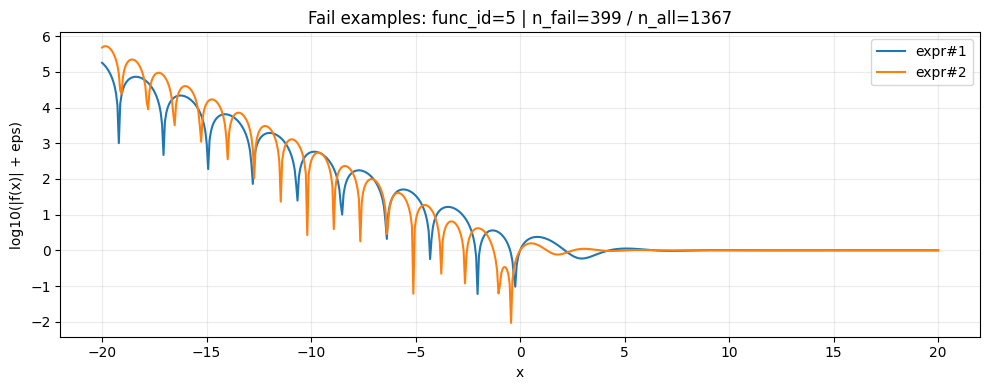

Saved PNG : /home/seokjun/taylor-root-prediction/results/runs_k_sweep_viz/failure_examples/fail_example_funcid_12.png
Saved PDF : /home/seokjun/taylor-root-prediction/results/runs_k_sweep_viz/failure_examples/fail_example_funcid_12.pdf
Saved SVG : /home/seokjun/taylor-root-prediction/results/runs_k_sweep_viz/failure_examples/fail_example_funcid_12.svg


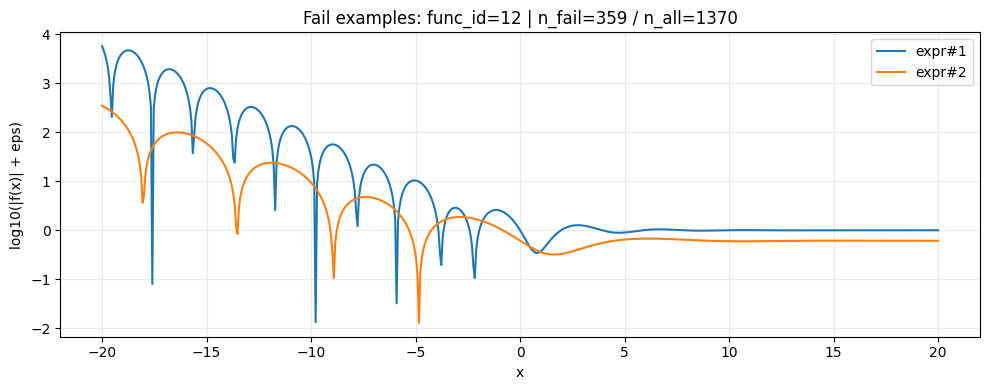

Saved PNG : /home/seokjun/taylor-root-prediction/results/runs_k_sweep_viz/failure_examples/fail_example_funcid_6.png
Saved PDF : /home/seokjun/taylor-root-prediction/results/runs_k_sweep_viz/failure_examples/fail_example_funcid_6.pdf
Saved SVG : /home/seokjun/taylor-root-prediction/results/runs_k_sweep_viz/failure_examples/fail_example_funcid_6.svg


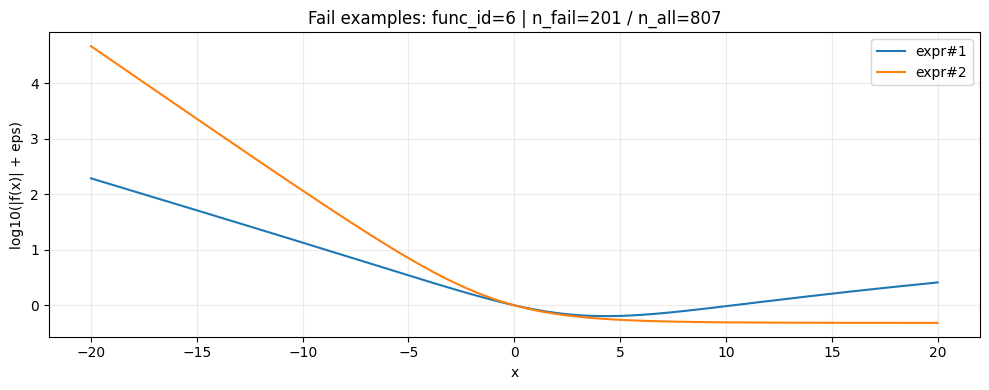

Saved PNG : /home/seokjun/taylor-root-prediction/results/runs_k_sweep_viz/failure_examples/fail_example_funcid_10.png
Saved PDF : /home/seokjun/taylor-root-prediction/results/runs_k_sweep_viz/failure_examples/fail_example_funcid_10.pdf
Saved SVG : /home/seokjun/taylor-root-prediction/results/runs_k_sweep_viz/failure_examples/fail_example_funcid_10.svg


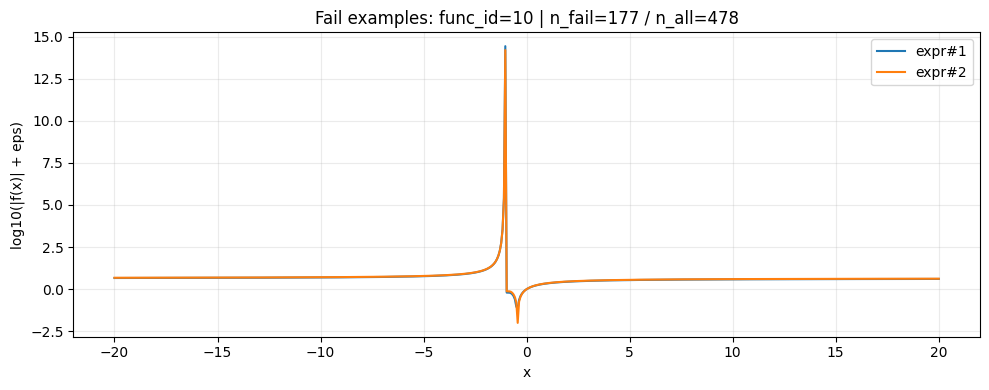

Saved PNG : /home/seokjun/taylor-root-prediction/results/runs_k_sweep_viz/failure_examples/fail_example_funcid_0.png
Saved PDF : /home/seokjun/taylor-root-prediction/results/runs_k_sweep_viz/failure_examples/fail_example_funcid_0.pdf
Saved SVG : /home/seokjun/taylor-root-prediction/results/runs_k_sweep_viz/failure_examples/fail_example_funcid_0.svg


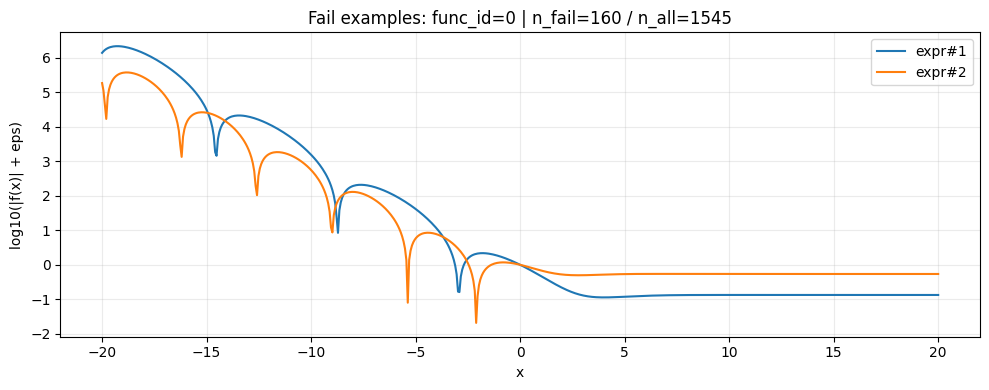

Saved PNG : /home/seokjun/taylor-root-prediction/results/runs_k_sweep_viz/failure_examples/fail_example_funcid_11.png
Saved PDF : /home/seokjun/taylor-root-prediction/results/runs_k_sweep_viz/failure_examples/fail_example_funcid_11.pdf
Saved SVG : /home/seokjun/taylor-root-prediction/results/runs_k_sweep_viz/failure_examples/fail_example_funcid_11.svg


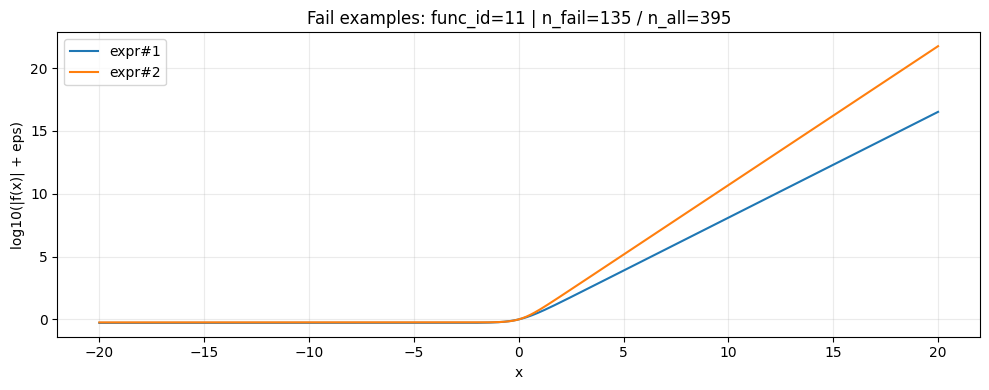

Saved PNG : /home/seokjun/taylor-root-prediction/results/runs_k_sweep_viz/failure_examples/fail_example_funcid_9.png
Saved PDF : /home/seokjun/taylor-root-prediction/results/runs_k_sweep_viz/failure_examples/fail_example_funcid_9.pdf
Saved SVG : /home/seokjun/taylor-root-prediction/results/runs_k_sweep_viz/failure_examples/fail_example_funcid_9.svg


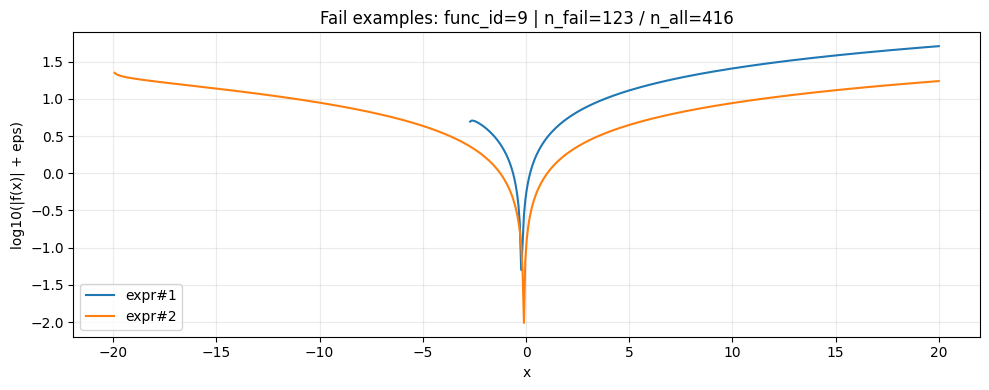

Saved PNG : /home/seokjun/taylor-root-prediction/results/runs_k_sweep_viz/failure_examples/fail_example_funcid_1.png
Saved PDF : /home/seokjun/taylor-root-prediction/results/runs_k_sweep_viz/failure_examples/fail_example_funcid_1.pdf
Saved SVG : /home/seokjun/taylor-root-prediction/results/runs_k_sweep_viz/failure_examples/fail_example_funcid_1.svg


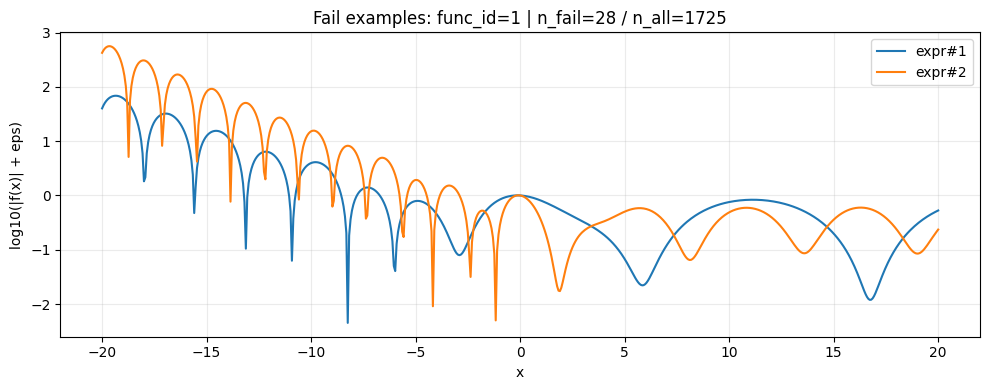

[SKIP] func_id=2: no expr_examples
[SKIP] func_id=3: no expr_examples
[SKIP] func_id=13: no expr_examples


In [12]:
import json
import re
import math
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# --------------------------------------------------
# 경로 유틸
# --------------------------------------------------
# R(), REPO 가 기존 노트북/프로젝트에서 이미 정의돼 있지 않다면
# 아래 두 줄을 환경에 맞게 수정하세요.
REPO = Path(".").resolve()

def R(rel_path: str) -> Path:
    return REPO / rel_path

# --------------------------------------------------
# 수식 문자열 정리
# --------------------------------------------------
def sanitize_expr_for_eval(raw: str) -> str:
    s = str(raw).strip()

    if "= 0" in s:
        s = s.split("= 0")[0].strip()
    elif "=0" in s:
        s = s.split("=0")[0].strip()

    # 맨 끝의 괄호 설명 제거
    s = re.sub(r"\s*\([^()]*\)\s*$", "", s).strip()

    # 거듭제곱 표기 변환
    s = s.replace("^", "**")

    # 혹시 이미 np.가 붙어 있는 경우 중복 방지용으로 잠깐 제거
    s = re.sub(r"\bnp\.", "", s)

    # 긴 이름 먼저 치환해야 log -> np.log 가 log10을 깨지 않음
    replacements = [
        ("log10", "np.log10"),
        ("sqrt", "np.sqrt"),
        ("tanh", "np.tanh"),
        ("sinh", "np.sinh"),
        ("cosh", "np.cosh"),
        ("exp", "np.exp"),
        ("sin", "np.sin"),
        ("cos", "np.cos"),
        ("tan", "np.tan"),
        ("log", "np.log"),
        ("abs", "np.abs"),
    ]

    for src, dst in replacements:
        s = re.sub(rf"(?<!np\.)\b{src}\s*\(", f"{dst}(", s)

    s = re.sub(r"\bln\s*\(", "np.log(", s)

    return s

# --------------------------------------------------
# eval callable 생성
# --------------------------------------------------
def make_callable(expr_sanitized: str):
    code = compile(expr_sanitized, "<expr>", "eval")
    allowed = {"np": np, "math": math}

    def f(x):
        with np.errstate(all="ignore"):
            return eval(code, {"__builtins__": {}}, {**allowed, "x": x})

    return f

# --------------------------------------------------
# 메인 실행
# --------------------------------------------------
outdir = R("results/runs_k_sweep_viz")
jsons = sorted(outdir.rglob("fail_by_funcid_*.json"))

if not jsons:
    print("[INFO] No fail_by_funcid_*.json found. Turn on reports.report_fail_save: true and rerun evaluation.")
else:
    path = jsons[0]
    print("Using:", path.relative_to(REPO))

    rows = json.loads(path.read_text(encoding="utf-8"))

    # 저장 폴더
    save_dir = outdir / "failure_examples"
    save_dir.mkdir(parents=True, exist_ok=True)
    print("Save dir:", save_dir)

    # 필요하면 일부만 쓰세요. 예: rows[:5]
    for r in rows[:]:
        fid = r.get("func_id")
        n_fail = r.get("n_fail")
        n_all = r.get("n_all")
        exs = r.get("expr_examples", [])[:2]   # expr 2개만 사용

        if not exs:
            print(f"[SKIP] func_id={fid}: no expr_examples")
            continue

        xs = np.linspace(-20, 20, 600)

        fig, ax = plt.subplots(figsize=(10, 4))
        plotted = 0

        for i, e in enumerate(exs):
            san = sanitize_expr_for_eval(e)
            try:
                f = make_callable(san)
                ys = f(xs)
                ys = np.asarray(ys, dtype=float)

                # 유효하지 않은 값 처리
                ys = np.where(np.isfinite(ys), ys, np.nan)

                ax.plot(
                    xs,
                    np.log10(np.abs(ys) + 1e-30),
                    label=f"expr#{i+1}"
                )
                plotted += 1

            except Exception as ex:
                print(f"[WARN] func_id={fid}, expr#{i+1} plot failed: {ex}")
                continue

        if plotted == 0:
            plt.close(fig)
            print(f"[SKIP] func_id={fid}: no valid plot")
            continue

        ax.set_title(f"Fail examples: func_id={fid} | n_fail={n_fail} / n_all={n_all}")
        ax.set_xlabel("x")
        ax.set_ylabel("log10(|f(x)| + eps)")
        ax.grid(True, alpha=0.25)
        ax.legend()

        plt.tight_layout()

        # ------------------------------------------
        # 저장: PNG + PDF + SVG
        # PNG  : 래스터
        # PDF  : 벡터
        # SVG  : 벡터
        # ------------------------------------------
        png_path = save_dir / f"fail_example_funcid_{fid}.png"
        pdf_path = save_dir / f"fail_example_funcid_{fid}.pdf"
        svg_path = save_dir / f"fail_example_funcid_{fid}.svg"

        fig.savefig(png_path, dpi=300, bbox_inches="tight")
        fig.savefig(pdf_path, bbox_inches="tight")
        fig.savefig(svg_path, bbox_inches="tight")

        print("Saved PNG :", png_path)
        print("Saved PDF :", pdf_path)
        print("Saved SVG :", svg_path)

        plt.show()
        plt.close(fig)

In [13]:
# =========================================
# 9) Failure taxonomy setup
# =========================================
from pathlib import Path
import pandas as pd
import numpy as np

# 대표 failure func_id 8개
REP_FUNC_IDS = [10, 0, 11, 9, 1, 5, 12, 6]

# 논문 Table III / 현재 failure 해석 기준으로 수동 매핑
FUNC_META = {
    10: {
        "family": "Arrhenius-like",
        "mechanism": "radius-limited / nearby singularity",
        "short_reason": "singularity near x=-1 restricts local Maclaurin validity"
    },
    0: {
        "family": "Damped oscillator 1",
        "mechanism": "oscillation + damping / phase drift",
        "short_reason": "repeated oscillatory roots become misaligned far from center"
    },
    11: {
        "family": "Diode I-V",
        "mechanism": "steep exponential growth / coefficient explosion",
        "short_reason": "rapid exponential growth amplifies residual mismatch"
    },
    9: {
        "family": "Activation + logarithmic term",
        "mechanism": "nonuniform local sensitivity / logarithmic boundary effect",
        "short_reason": "log-shaped local sensitivity causes asymmetric mismatch"
    },
    1: {
        "family": "Damped oscillator 2",
        "mechanism": "mixed oscillatory interference",
        "short_reason": "multiple oscillatory components produce unstable local matching"
    },
    5: {
        "family": "Damped sine current",
        "mechanism": "oscillation + damping / phase drift",
        "short_reason": "many repeated roots with damping accumulate phase error"
    },
    12: {
        "family": "Damped wave",
        "mechanism": "oscillation + damping / phase drift",
        "short_reason": "damped wave roots drift under truncated local representation"
    },
    6: {
        "family": "Heat fin",
        "mechanism": "global shape mismatch / curvature loss",
        "short_reason": "global curvature is not preserved well by fixed local truncation"
    },
}

# fail_by_funcid CSV 자동 탐색
outdir = R("results/runs_k_sweep_viz")
cands = sorted(outdir.glob("fail_by_funcid_*.csv"))
assert len(cands) > 0, "fail_by_funcid_*.csv 파일이 없습니다. evaluation을 먼저 실행하세요."

fail_csv = cands[0]
df_fail = pd.read_csv(fail_csv)
print("Using fail csv:", fail_csv)

# 컬럼명 확인
print("Columns:", df_fail.columns.tolist())
display(df_fail.head())

Using fail csv: /home/seokjun/taylor-root-prediction/results/runs_k_sweep_viz/fail_by_funcid_all_K50_thr1e-10.csv
Columns: ['func_id', 'n_fail', 'n_all', 'fail_rate', 'top_reasons']


,func_id,n_fail,n_all,fail_rate,top_reasons
0,5,399,1367,0.291880,baseline_fail:no_bracket:399
1,12,359,1370,0.262044,baseline_fail:no_bracket:359
2,6,201,807,0.249071,baseline_fail:no_bracket:201
3,10,177,478,0.370293,baseline_fail:no_bracket:177
4,0,160,1545,0.103560,baseline_fail:no_bracket:160


,func_id,family,n_all,n_fail,failure_rate,mechanism
0,5,Damped sine current,1367,399,0.291880,oscillation + damping / phase drift
1,12,Damped wave,1370,359,0.262044,oscillation + damping / phase drift
2,6,Heat fin,807,201,0.249071,global shape mismatch / curvature loss
3,10,Arrhenius-like,478,177,0.370293,radius-limited / nearby singularity
4,0,Damped oscillator 1,1545,160,0.103560,oscillation + damping / phase drift
5,11,Diode I-V,395,135,0.341772,steep exponential growth / coefficient explosion
6,9,Activation + logarithmic term,416,123,0.295673,nonuniform local sensitivity / logarithmic bou...
7,1,Damped oscillator 2,1725,28,0.016232,mixed oscillatory interference
8,2,func_id=2,889,0,0.000000,other
9,3,func_id=3,62,0,0.000000,other


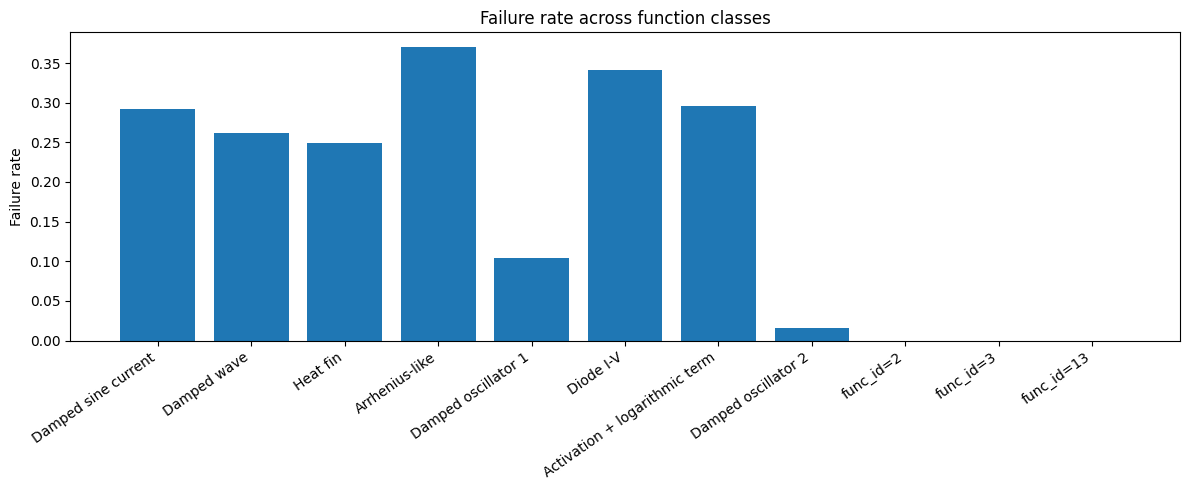

In [14]:
# =========================================
# 10) Family-wise failure summary table
# =========================================
import matplotlib.pyplot as plt

# 예상 컬럼:
# func_id, n_fail, n_all
# 없으면 실제 컬럼명에 맞게 수정
required_cols = ["func_id", "n_fail", "n_all"]
for c in required_cols:
    assert c in df_fail.columns, f"CSV에 '{c}' 컬럼이 없습니다."

df_plot = df_fail.copy()
df_plot["failure_rate"] = df_plot["n_fail"] / df_plot["n_all"]

# family 이름 붙이기
df_plot["family"] = df_plot["func_id"].map(lambda x: FUNC_META.get(int(x), {}).get("family", f"func_id={x}"))
df_plot["mechanism"] = df_plot["func_id"].map(lambda x: FUNC_META.get(int(x), {}).get("mechanism", "other"))

# 논문용 정렬: failure count 기준
df_plot = df_plot.sort_values(["n_fail", "failure_rate"], ascending=[False, False]).reset_index(drop=True)

display(df_plot[["func_id", "family", "n_all", "n_fail", "failure_rate", "mechanism"]])

plt.figure(figsize=(12, 5))
plt.bar(df_plot["family"], df_plot["failure_rate"])
plt.xticks(rotation=35, ha="right")
plt.ylabel("Failure rate")
plt.title("Failure rate across function classes")
plt.tight_layout()
plt.show()

In [15]:
from pathlib import Path

IMG_DIR = R("results/runs_k_sweep_viz/failure_examples")

img_map = {
    10: IMG_DIR / "fail_example_funcid_10.png",
    0:  IMG_DIR / "fail_example_funcid_0.png",
    11: IMG_DIR / "fail_example_funcid_11.png",
    9:  IMG_DIR / "fail_example_funcid_9.png",
    1:  IMG_DIR / "fail_example_funcid_1.png",
    5:  IMG_DIR / "fail_example_funcid_5.png",
    12: IMG_DIR / "fail_example_funcid_12.png",
    6:  IMG_DIR / "fail_example_funcid_6.png",
}

for fid, p in img_map.items():
    print(fid, "->", p, "| exists =", Path(p).exists())

10 -> /home/seokjun/taylor-root-prediction/results/runs_k_sweep_viz/failure_examples/fail_example_funcid_10.png | exists = True
0 -> /home/seokjun/taylor-root-prediction/results/runs_k_sweep_viz/failure_examples/fail_example_funcid_0.png | exists = True
11 -> /home/seokjun/taylor-root-prediction/results/runs_k_sweep_viz/failure_examples/fail_example_funcid_11.png | exists = True
9 -> /home/seokjun/taylor-root-prediction/results/runs_k_sweep_viz/failure_examples/fail_example_funcid_9.png | exists = True
1 -> /home/seokjun/taylor-root-prediction/results/runs_k_sweep_viz/failure_examples/fail_example_funcid_1.png | exists = True
5 -> /home/seokjun/taylor-root-prediction/results/runs_k_sweep_viz/failure_examples/fail_example_funcid_5.png | exists = True
12 -> /home/seokjun/taylor-root-prediction/results/runs_k_sweep_viz/failure_examples/fail_example_funcid_12.png | exists = True
6 -> /home/seokjun/taylor-root-prediction/results/runs_k_sweep_viz/failure_examples/fail_example_funcid_6.png | 

Saved: failure_cases_montage.png
Saved: failure_cases_montage.pdf
Saved: failure_cases_montage.svg


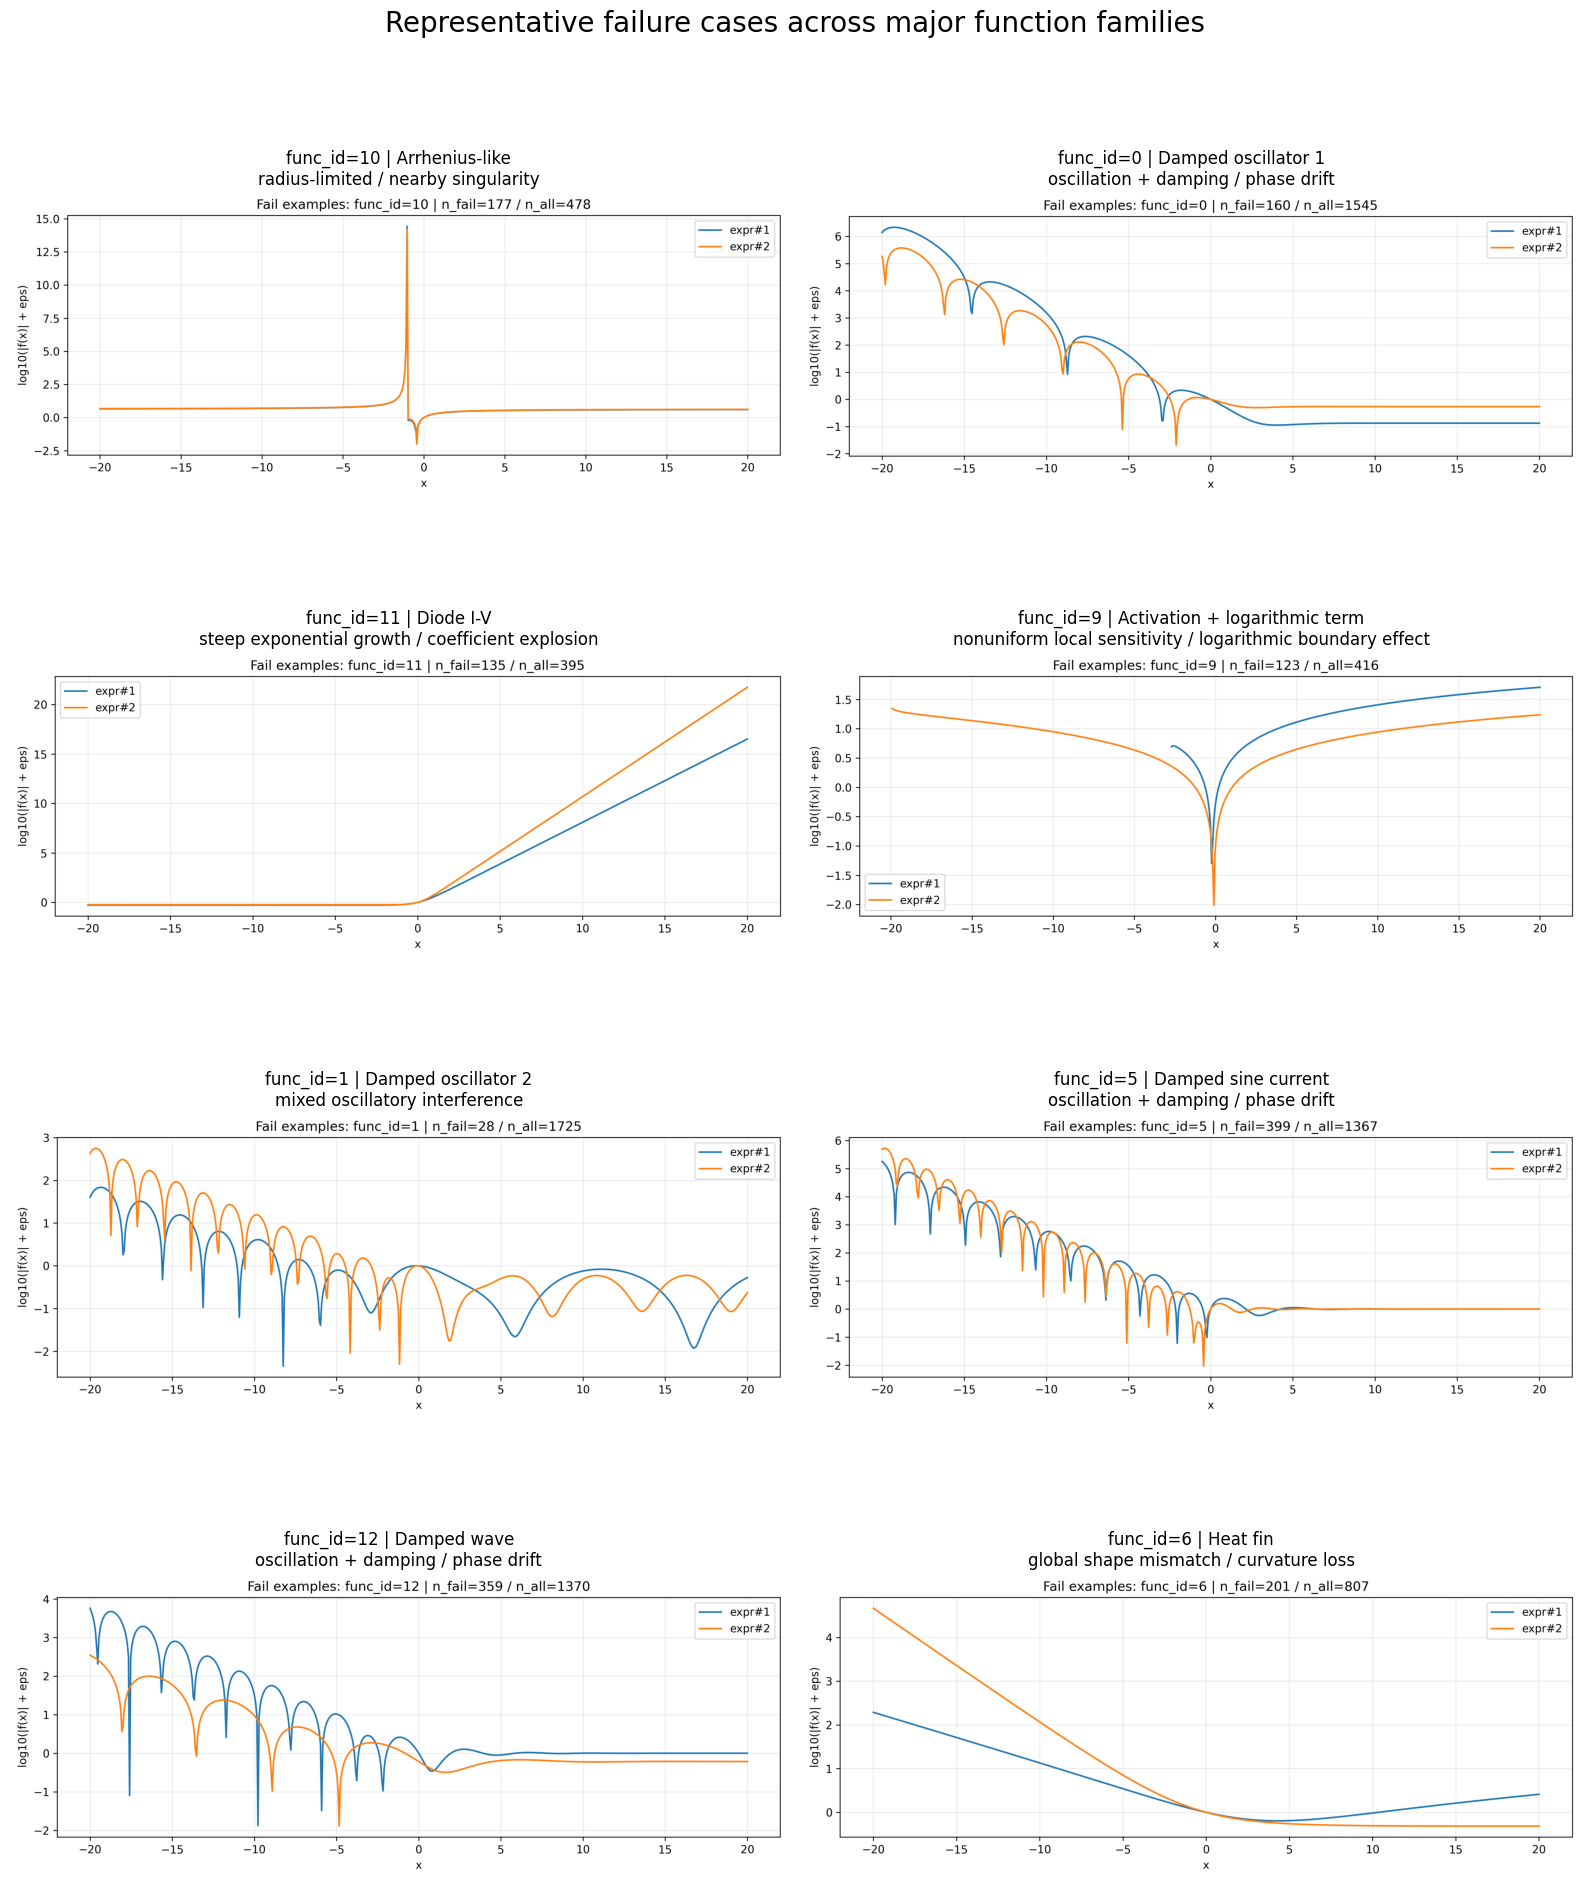

In [16]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

# --------------------------------------------------
# 선택: 벡터 출력 시 텍스트 처리 개선
# --------------------------------------------------
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42
plt.rcParams["svg.fonttype"] = "none"

# --------------------------------------------------
# 필수 입력 예시
# REP_FUNC_IDS: [10, 11, 9, 5, 12, 6, 0, 1] 같은 리스트
# img_map: {10: "/path/to/a.png", 11: "/path/to/b.png", ...}
# FUNC_META: {
#   10: {"family": "Arrhenius-like", "mechanism": "Radius-limited / nearby singularity"},
#   ...
# }
# --------------------------------------------------

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.ravel()

for ax, fid in zip(axes, REP_FUNC_IDS):
    p = img_map.get(fid, None)
    meta = FUNC_META[fid]
    title = f"func_id={fid} | {meta['family']}\n{meta['mechanism']}"

    if p is not None and Path(p).exists():
        img = mpimg.imread(p)
        ax.imshow(img)
        ax.set_title(title, fontsize=12)
        ax.axis("off")
    else:
        ax.text(
            0.5, 0.5,
            f"[Image not found]\nfunc_id={fid}\n{meta['family']}",
            ha="center", va="center", fontsize=12
        )
        ax.set_title(title, fontsize=12)
        ax.axis("off")

# 남는 축이 있으면 끄기
for ax in axes[len(REP_FUNC_IDS):]:
    ax.axis("off")

plt.suptitle(
    "Representative failure cases across major function families",
    fontsize=20,
    y=0.995
)

plt.tight_layout(rect=[0, 0, 1, 0.985])

# --------------------------------------------------
# 저장
# PNG: 고해상도 래스터
# PDF: 벡터 컨테이너
# SVG: 벡터 컨테이너
# --------------------------------------------------
out_png = "failure_cases_montage.png"
out_pdf = "failure_cases_montage.pdf"
out_svg = "failure_cases_montage.svg"

plt.savefig(out_png, dpi=600, bbox_inches="tight")
plt.savefig(out_pdf, bbox_inches="tight")
plt.savefig(out_svg, bbox_inches="tight")

print("Saved:", out_png)
print("Saved:", out_pdf)
print("Saved:", out_svg)

plt.show()

In [17]:
# =========================================
# 13) Failure taxonomy table
# =========================================
rows = []
for fid in REP_FUNC_IDS:
    row0 = df_plot[df_plot["func_id"] == fid]
    if len(row0) == 0:
        n_fail, n_all, fr = np.nan, np.nan, np.nan
    else:
        n_fail = int(row0.iloc[0]["n_fail"])
        n_all = int(row0.iloc[0]["n_all"])
        fr = float(row0.iloc[0]["failure_rate"])

    rows.append({
        "func_id": fid,
        "family": FUNC_META[fid]["family"],
        "n_fail": n_fail,
        "n_all": n_all,
        "failure_rate": fr,
        "mechanism": FUNC_META[fid]["mechanism"],
        "short_reason": FUNC_META[fid]["short_reason"],
    })

df_tax = pd.DataFrame(rows)
display(df_tax)

save_csv = outdir / "representative_failure_taxonomy.csv"
df_tax.to_csv(save_csv, index=False)
print("Saved:", save_csv)

,func_id,family,n_fail,n_all,failure_rate,mechanism,short_reason
0,10,Arrhenius-like,177,478,0.370293,radius-limited / nearby singularity,singularity near x=-1 restricts local Maclauri...
1,0,Damped oscillator 1,160,1545,0.103560,oscillation + damping / phase drift,repeated oscillatory roots become misaligned f...
2,11,Diode I-V,135,395,0.341772,steep exponential growth / coefficient explosion,rapid exponential growth amplifies residual mi...
3,9,Activation + logarithmic term,123,416,0.295673,nonuniform local sensitivity / logarithmic bou...,log-shaped local sensitivity causes asymmetric...
4,1,Damped oscillator 2,28,1725,0.016232,mixed oscillatory interference,multiple oscillatory components produce unstab...
5,5,Damped sine current,399,1367,0.291880,oscillation + damping / phase drift,many repeated roots with damping accumulate ph...
6,12,Damped wave,359,1370,0.262044,oscillation + damping / phase drift,damped wave roots drift under truncated local ...
7,6,Heat fin,201,807,0.249071,global shape mismatch / curvature loss,global curvature is not preserved well by fixe...


Saved: /home/seokjun/taylor-root-prediction/results/runs_k_sweep_viz/representative_failure_taxonomy.csv


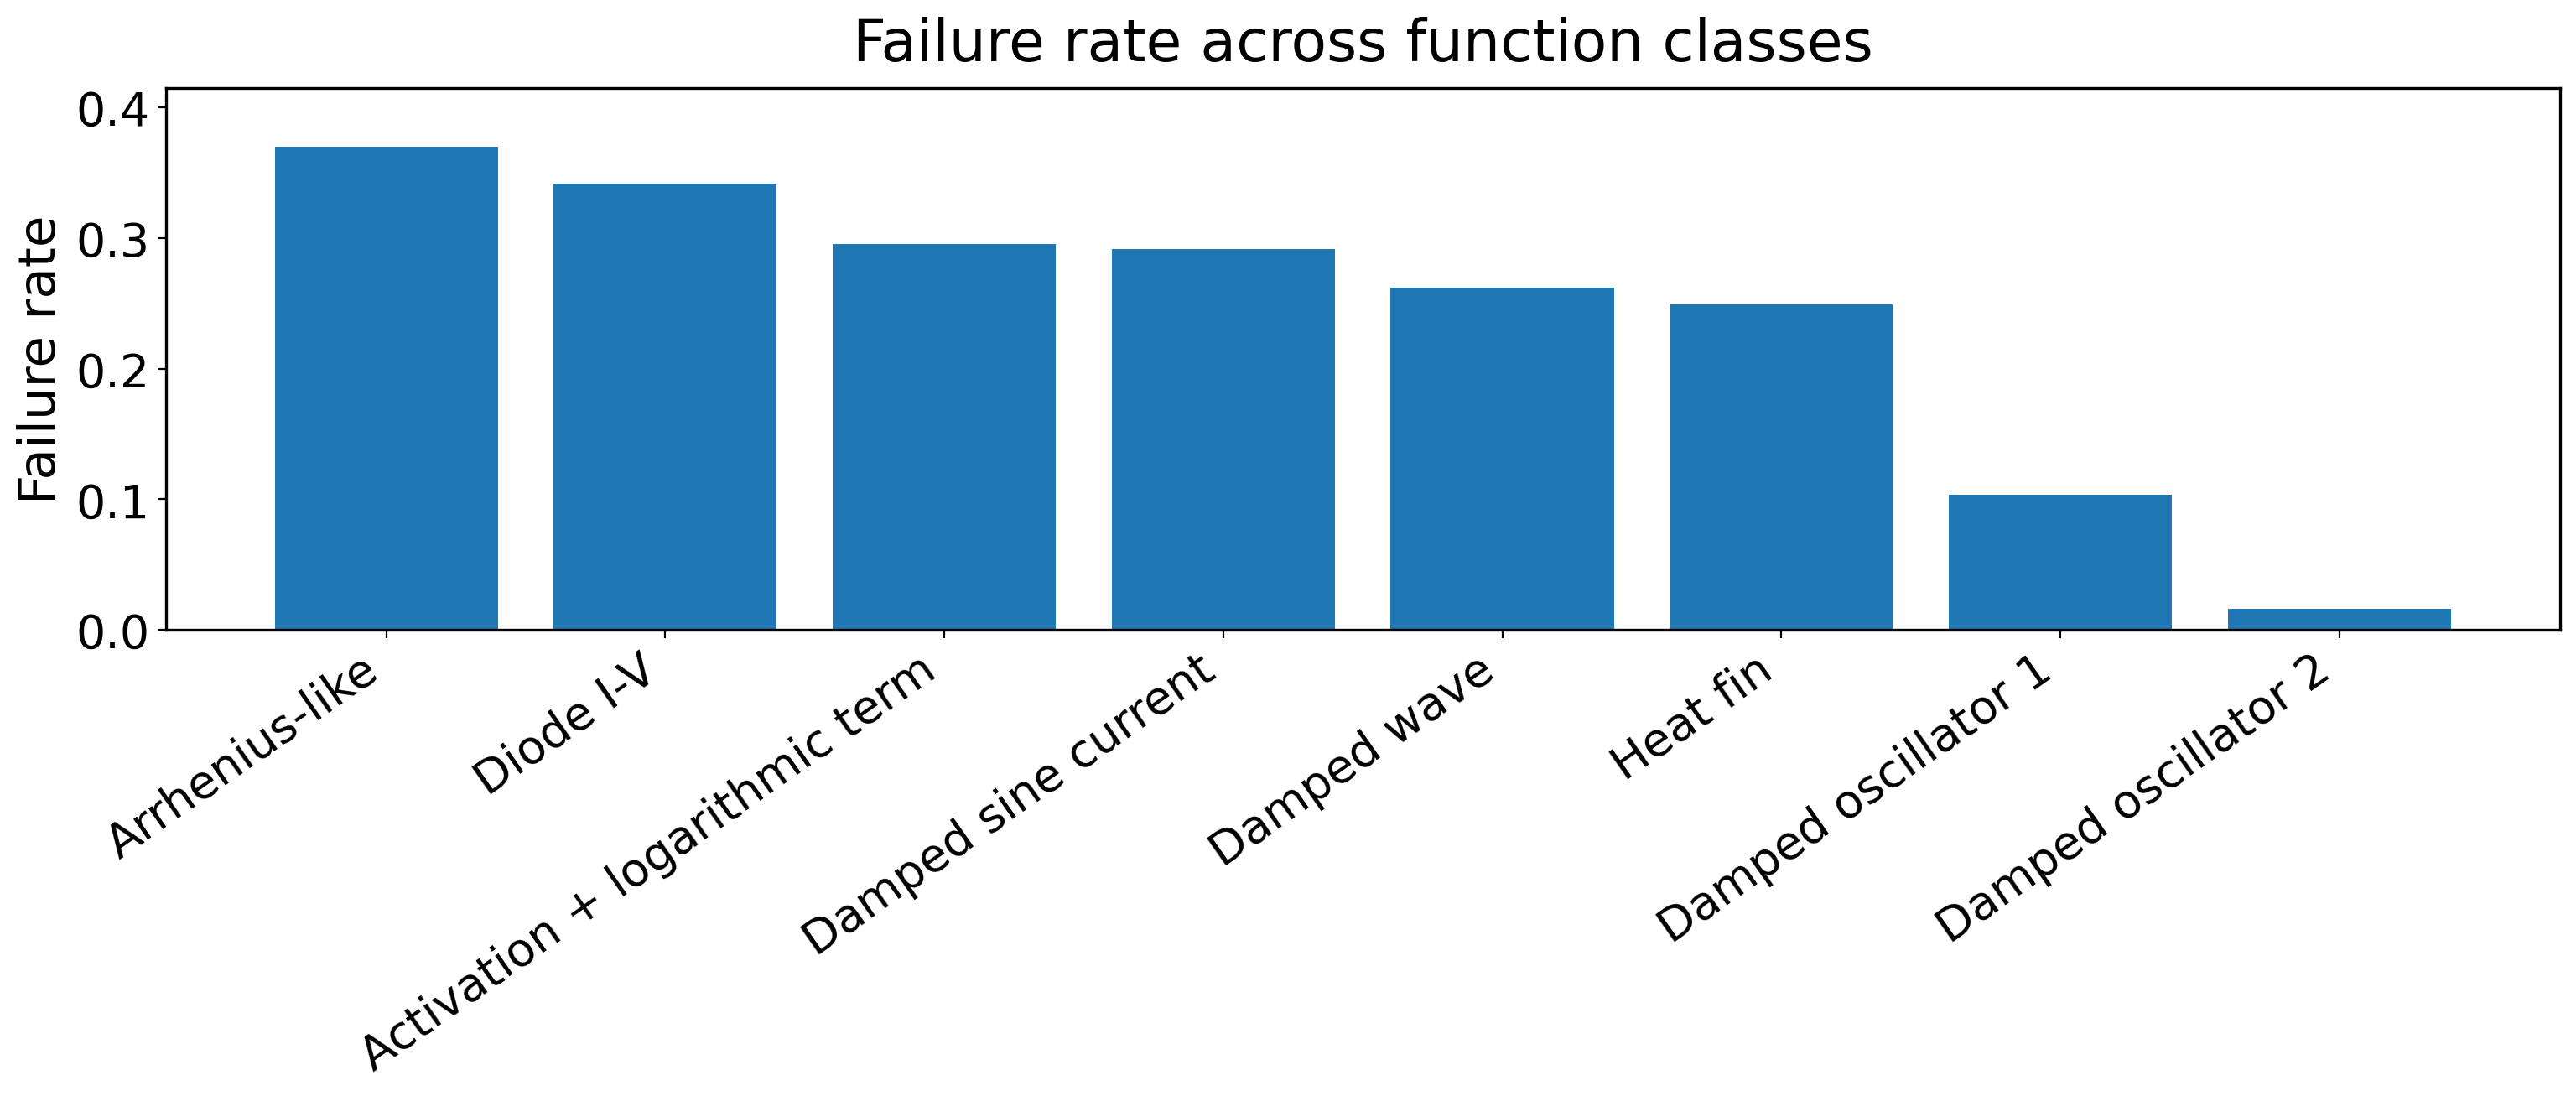

Saved: /home/seokjun/taylor-root-prediction/results/runs_k_sweep_viz/failure_rate_across_function_classes_hi.png
Saved: /home/seokjun/taylor-root-prediction/results/runs_k_sweep_viz/failure_rate_across_function_classes_hi.pdf


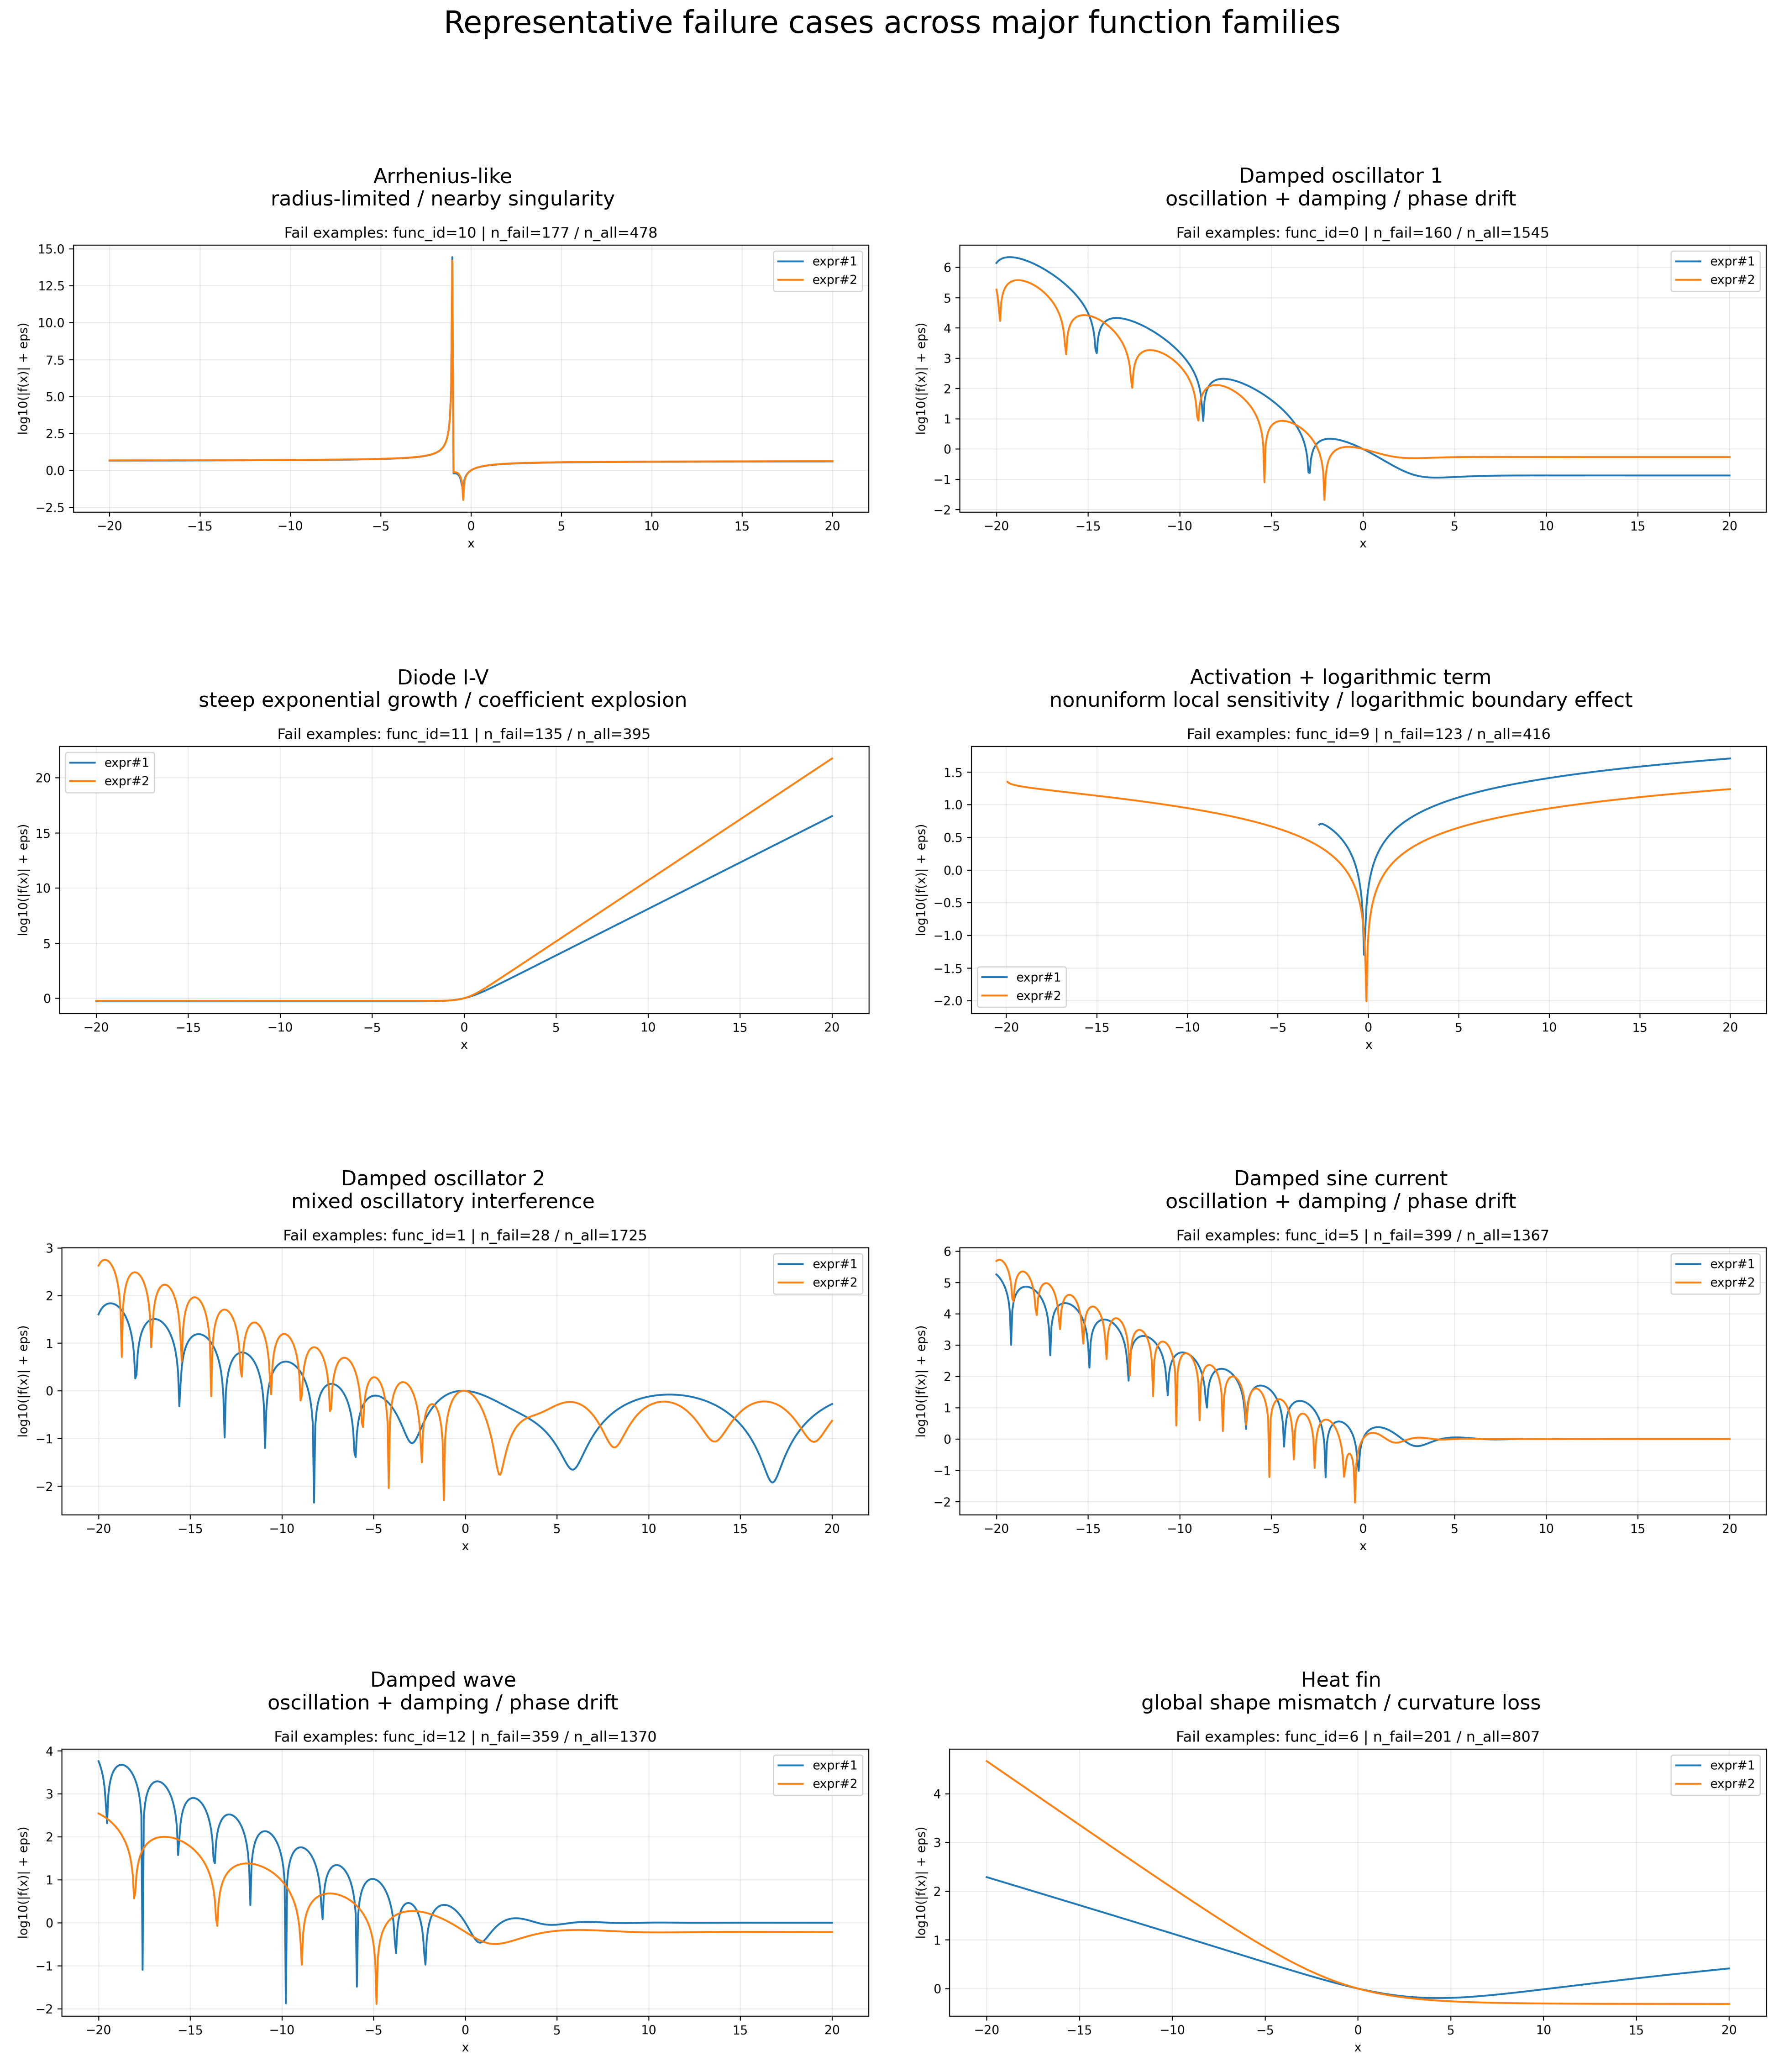

Saved: /home/seokjun/taylor-root-prediction/results/runs_k_sweep_viz/representative_failure_cases_8panel_hi.png
Saved: /home/seokjun/taylor-root-prediction/results/runs_k_sweep_viz/representative_failure_cases_8panel_hi.pdf


In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib as mpl

# =========================================
# Global style for publication-quality figures
# =========================================
mpl.rcParams.update({
    "figure.dpi": 200,          # 화면 표시용
    "savefig.dpi": 900,         # 저장용: 600보다 더 선명
    "font.size": 25,
    "axes.titlesize": 30,
    "axes.labelsize": 25,
    "xtick.labelsize": 25,
    "ytick.labelsize": 25,
    "legend.fontsize": 25,
    "figure.titlesize": 25,
    "axes.linewidth": 1.2,
    "lines.linewidth": 2.0,
    "patch.linewidth": 1.0,
    "savefig.bbox": "tight",
    "savefig.facecolor": "white",
    "figure.facecolor": "white",
})

# -------------------------------------------------
# A) Failure-rate bar chart
# -------------------------------------------------
df_plot_clean = df_plot.copy()
df_plot_clean = df_plot_clean[df_plot_clean["failure_rate"] > 0]
df_plot_clean = df_plot_clean[
    ~df_plot_clean["family"].astype(str).str.startswith("func_id=")
]
df_plot_clean = df_plot_clean.sort_values("failure_rate", ascending=False)

# 폭/높이 둘 다 키움
fig, ax = plt.subplots(figsize=(16, 7))

ax.bar(df_plot_clean["family"], df_plot_clean["failure_rate"])
ax.set_ylabel("Failure rate")
ax.set_title("Failure rate across function classes", pad=12)
plt.xticks(rotation=35, ha="right")

# y축 살짝 여유
ymax = df_plot_clean["failure_rate"].max()
ax.set_ylim(0, ymax * 1.12)

fig.tight_layout()

bar_path_png = outdir / "failure_rate_across_function_classes_hi.png"
bar_path_pdf = outdir / "failure_rate_across_function_classes_hi.pdf"

fig.savefig(bar_path_png, dpi=900)
fig.savefig(bar_path_pdf)   # 벡터라 dpi 의미 거의 없음
plt.show()

print("Saved:", bar_path_png)
print("Saved:", bar_path_pdf)

# -------------------------------------------------
# B) 4x2 montage of representative failure cases
# -------------------------------------------------
fig, axes = plt.subplots(4, 2, figsize=(20, 24))
axes = axes.ravel()

for ax, fid in zip(axes, REP_FUNC_IDS):
    p = img_map.get(fid, None)
    meta = FUNC_META[fid]
    title = f"{meta['family']}\n{meta['mechanism']}"

    if p is not None and Path(p).exists():
        img = mpimg.imread(p)
        ax.imshow(img)
        ax.set_title(title, fontsize=16, pad=10)
        ax.axis("off")
    else:
        ax.text(
            0.5, 0.5,
            f"[Image not found]\nfunc_id={fid}\n{meta['family']}",
            ha="center", va="center", fontsize=15
        )
        ax.set_title(title, fontsize=16, pad=10)
        ax.axis("off")

for ax in axes[len(REP_FUNC_IDS):]:
    ax.axis("off")

fig.suptitle(
    "Representative failure cases across major function families",
    fontsize=24,
    y=0.995
)

fig.tight_layout(rect=[0, 0, 1, 0.985])

montage_path_png = outdir / "representative_failure_cases_8panel_hi.png"
montage_path_pdf = outdir / "representative_failure_cases_8panel_hi.pdf"

fig.savefig(montage_path_png, dpi=900)
fig.savefig(montage_path_pdf)
plt.show()

print("Saved:", montage_path_png)
print("Saved:", montage_path_pdf)